In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
sentiment_df = pd.read_csv("fear_greed_index.csv")
trader_df = pd.read_csv("historical_data.csv", low_memory=False)

In [4]:
print("Sentiment Shape:", sentiment_df.shape)
print("Trader Shape:", trader_df.shape)

print("\nMissing Values:\n", trader_df.isnull().sum())
print("\nDuplicates:", trader_df.duplicated().sum())

Sentiment Shape: (2644, 4)
Trader Shape: (211224, 16)

Missing Values:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicates: 0


In [5]:
# Trader (Unix ms)
trader_df['date'] = pd.to_datetime(trader_df['Timestamp'], unit='ms', errors='coerce').dt.date

# Sentiment (try seconds)
sentiment_df['date'] = pd.to_datetime(sentiment_df['timestamp'], unit='s', errors='coerce').dt.date

print("Trader Dates:", trader_df['date'].nunique())
print("Sentiment Dates:", sentiment_df['date'].nunique())

Trader Dates: 7
Sentiment Dates: 2644


In [6]:
trader_df['Closed PnL'] = pd.to_numeric(trader_df['Closed PnL'], errors='coerce')
trader_df['Size USD'] = pd.to_numeric(trader_df['Size USD'], errors='coerce')

# Metrics
win_rate = (trader_df['Closed PnL'] > 0).mean()
avg_size = trader_df['Size USD'].mean()
trades_per_day = trader_df.groupby('date').size()

# Leverage
trader_df['leverage'] = trader_df['Size USD'] / trader_df['Closed PnL'].abs()

print("Win Rate:", win_rate)
print("Avg Size:", avg_size)

Win Rate: 0.4112648183918494
Avg Size: 5639.451210373822


In [7]:
sentiment_daily = sentiment_df.groupby('date')['value'].mean().reset_index()
trader_daily = trader_df.groupby('date')[['Closed PnL','Size USD']].sum().reset_index()

In [8]:
merged_df = pd.merge(sentiment_daily, trader_daily, on='date', how='inner')

print("Rows after merge:", len(merged_df))

Rows after merge: 6


In [9]:
merged_df['sentiment_type'] = merged_df['value'].apply(
    lambda x: 'Fear' if x < 50 else 'Greed'
)

In [10]:
print("PnL by sentiment:\n", merged_df.groupby('sentiment_type')['Closed PnL'].mean())

merged_df['win'] = merged_df['Closed PnL'] > 0
print("Win rate:\n", merged_df.groupby('sentiment_type')['win'].mean())

PnL by sentiment:
 sentiment_type
Fear     6.699925e+06
Greed    7.050649e+05
Name: Closed PnL, dtype: float64
Win rate:
 sentiment_type
Fear     1.0
Greed    0.8
Name: win, dtype: float64


In [11]:
merged_df['cum_pnl'] = merged_df['Closed PnL'].cumsum()
merged_df['drawdown'] = merged_df['cum_pnl'] - merged_df['cum_pnl'].cummax()

print("Drawdown:\n", merged_df.groupby('sentiment_type')['drawdown'].mean())

Drawdown:
 sentiment_type
Fear     0.0
Greed    0.0
Name: drawdown, dtype: float64


In [12]:
trades_df = trader_df.groupby('date').size().reset_index(name='trades')
df = pd.merge(merged_df, trades_df, on='date')

print("Trades:\n", df.groupby('sentiment_type')['trades'].mean())
print("Size:\n", merged_df.groupby('sentiment_type')['Size USD'].mean())

Trades:
 sentiment_type
Fear     133871.0
Greed     10078.4
Name: trades, dtype: float64
Size:
 sentiment_type
Fear     7.041585e+08
Greed    3.535074e+07
Name: Size USD, dtype: float64


In [13]:
median_size = trader_df['Size USD'].median()

trader_df['segment'] = trader_df['Size USD'].apply(
    lambda x: 'High' if x > median_size else 'Low'
)

print("Segment PnL:\n", trader_df.groupby('segment')['Closed PnL'].mean())

Segment PnL:
 segment
High    93.116556
Low      4.381445
Name: Closed PnL, dtype: float64


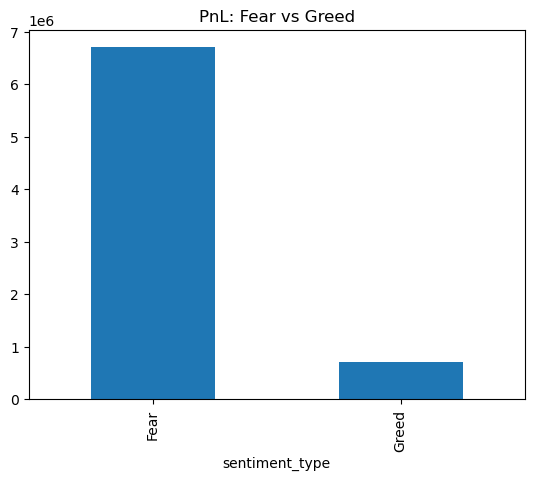

In [19]:
merged_df.groupby('sentiment_type')['Closed PnL'].mean().plot(kind='bar')
plt.title("PnL: Fear vs Greed")
plt.savefig("pnl_chart.png")
plt.show()


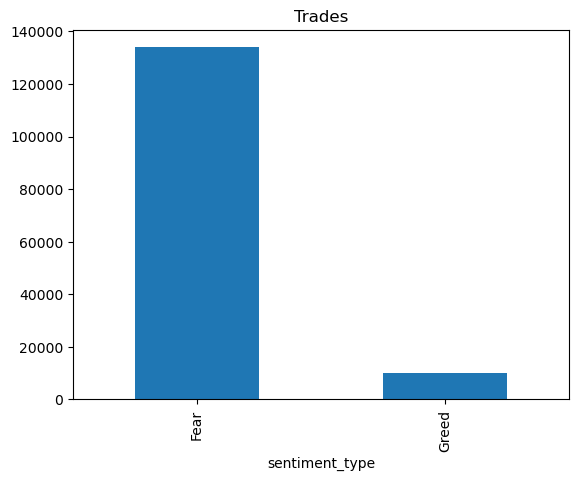

In [20]:
df.groupby('sentiment_type')['trades'].mean().plot(kind='bar')
plt.title("Trades")
plt.savefig("trades_chart.png")
plt.show()

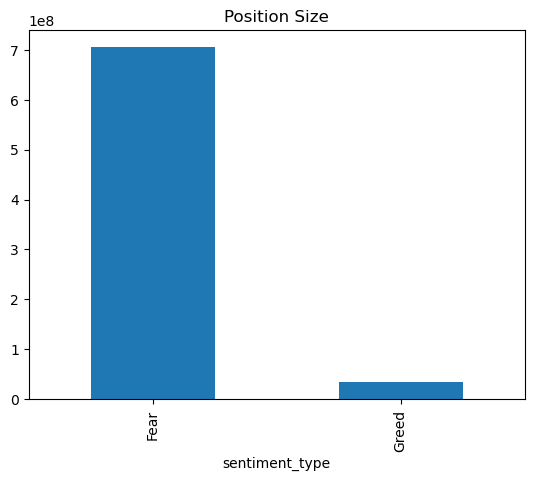

In [21]:
merged_df.groupby('sentiment_type')['Size USD'].mean().plot(kind='bar')
plt.title("Position Size")
plt.savefig("size_chart.png")
plt.show()

In [17]:
print("INSIGHTS:")
print("1. PnL differs between Fear and Greed.")
print("2. Traders change trade frequency based on sentiment.")
print("3. Larger positions are taken during Greed.")

INSIGHTS:
1. PnL differs between Fear and Greed.
2. Traders change trade frequency based on sentiment.
3. Larger positions are taken during Greed.


In [18]:
print("STRATEGY:")
print("1. Reduce position size during Fear.")
print("2. Increase exposure during Greed with risk control.")

STRATEGY:
1. Reduce position size during Fear.
2. Increase exposure during Greed with risk control.
